# M3/S1: LLM Benchmark — Zero-Shot Token-Level Classification

**Cíl:** Evaluovat LLM (Gemma 3 27B) v režimu Zero-Shot na detekci subjektivních/hodnotících slov (LJMPNIK) na úrovni tokenů.

**Scénář:** S1a — Baseline (Gold target sentences, aggressive POS filtr).

**Srovnání:**
- Dummy (Majority) — absolutní baseline
- Nejlepší M2/S1 model (supervised, z `M2_S1_experiment_results_v3.csv`)
- Gemma 3 (27B) — Zero-Shot LLM

## 1. Setup & Imports

In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, average_precision_score
)
from sklearn.dummy import DummyClassifier

# Auto-reload modules for development
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Add src to path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

# Import custom modules
import config
import data_splitting
import models
import visualization
import evaluation
from llm_client import LLMClassifier

# Setup visualization style
visualization.setup_style()

print(f"\u2705 Setup complete. Data dir: {config.DATA_DIR}")

⚙️ Configuration loaded. Device: cpu


2026-03-13 11:33:08,126 - INFO - Visualization style applied (ggplot + Set2).


✅ Setup complete. Data dir: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data


## 2. Načtení Testovacích Dat (Token-Level Baseline)

Používáme **stejný split** jako v M2/S1 — Gold target sentences, aggressive POS filtr.
Metadata obsahují sloupce `form` (token), `sentence_id`, `document_id`, `pos`.

In [2]:
# Načtení Baseline scénáře (S1a) na token úrovni
data = data_splitting.get_train_val_test_splits(
    scenario='baseline',
    level='token',
    filter_type='aggressive',
    random_state=42
)

# Extrakce test setu
df_test = data['meta_test'].copy()
df_test['true_label'] = data['y_test']

# Rekonstrukce kontextu věty z tokenů (seskupení podle sentence_id)
sentence_texts = df_test.groupby('sentence_id')['form'].apply(lambda x: ' '.join(x)).to_dict()
df_test['sentence_context'] = df_test['sentence_id'].map(sentence_texts)

print(f"\U0001f4ca Test Set Size: {len(df_test)} tokens")
print(f"   Unique sentences: {df_test['sentence_id'].nunique()}")
print(f"   Label distribution: L0={sum(df_test['true_label']==0)}, L1={sum(df_test['true_label']==1)}")
print(f"   Ratio: {sum(df_test['true_label']==0)/max(sum(df_test['true_label']==1),1):.1f}:1")
display(df_test.head(5))

2026-03-13 11:33:08,335 - INFO - 📊 Preparing scenario: baseline (token level, aggressive filter)
2026-03-13 11:33:08,962 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-13 11:33:12,151 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-13 11:33:12,206 - INFO - Splitting 520 documents: 104 test, 41 val, 375 train
2026-03-13 11:33:12,216 - INFO - ✅ Document-level split completed:
2026-03-13 11:33:12,218 - INFO -    Train: 376 docs, 2585 samples
2026-03-13 11:33:12,220 - INFO -    Val:   41 docs, 270 samples
2026-03-13 11:33:12,223 - INFO -    Test:  103 docs, 741 samples
2026-03-13 11:33:12,225 - INFO -    ✓ No document leakage detected between splits
2026-03-13 11:33:12,227 - INFO - ✅ Scenario data prepared:
2026-03-13 11:33:12,229 - INFO -    Train: 2585 samples (L0: 900, L1: 1685)
2026-03-13 11:33

📊 Test Set Size: 741 tokens
   Unique sentences: 103
   Label distribution: L0=695, L1=46
   Ratio: 15.1:1


,document_id,sentence_id,token_id,form,pos,true_label,sentence_context
66,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_0,Tempo,NOUN,0,Tempo výstavby nových bytů žalostné
67,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_1,výstavby,NOUN,0,Tempo výstavby nových bytů žalostné
68,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_2,nových,ADJ,0,Tempo výstavby nových bytů žalostné
69,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_3,bytů,NOUN,0,Tempo výstavby nových bytů žalostné
71,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_5,žalostné,ADJ,1,Tempo výstavby nových bytů žalostné


## 3. Definice LLM Modelu a Cesty

In [3]:
MODELS_TO_TEST = [
    {
        'id': 'gemma-3-27b',
        'provider': 'gemini',
        'model_name': 'gemma-3-27b-it',
        'display_name': 'Gemma 3 (27B)'
    }
]

# Cesta pro ukládání výsledků (průběžné predikce)
RESULTS_FILE = config.RESULTS_DIR / "M3_S1_LLM_predictions.csv"

print(f"\U0001f4be Results file: {RESULTS_FILE}")
print(f"\U0001f916 Models to test: {[m['display_name'] for m in MODELS_TO_TEST]}")

💾 Results file: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_LLM_predictions.csv
🤖 Models to test: ['Gemma 3 (27B)']


## 4. Inference Loop (Zero-Shot Token Classification)

Pro každý token sestavíme prompt, který obsahuje:
1. Celou větu jako kontext
2. Konkrétní slovo k posouzení

LLM rozhodne, zda dané slovo představuje subjektivní/hodnotící výraz.

In [6]:
# %%script false

# Načtení předchozích výsledků (pokud existují) pro resume
if RESULTS_FILE.exists():
    df_results = pd.read_csv(RESULTS_FILE)
    print(f"\u267b\ufe0f Načteny předchozí výsledky: {len(df_results)} řádků.")
else:
    df_results = df_test.copy()

for model_cfg in MODELS_TO_TEST:
    model_id = model_cfg['id']
    print(f"\n\U0001f680 Starting Inference for: {model_cfg['display_name']}...")
    
    try:
        clf = LLMClassifier(
            provider=model_cfg['provider'],
            model_name=model_cfg['model_name']
        )
    except Exception as e:
        print(f"\u274c Skipped model {model_id}: {e}")
        continue

    col_name = f"pred_{model_id}"
    if col_name not in df_results.columns:
        df_results[col_name] = np.nan
    
    # Zpracujeme jen řádky, kde ještě nemáme predikci
    missing_mask = df_results[col_name].isna()
    indices_to_process = df_results[missing_mask].index
    
    print(f"   -> Processing {len(indices_to_process)} tokens...")
    
    for i, idx in enumerate(tqdm(indices_to_process, desc=f"Asking {model_id}")):
        # Sestavení Token-Level promptu
        token_to_check = df_results.loc[idx, 'form']
        sentence_context = df_results.loc[idx, 'sentence_context']
        
        query_text = (
            f"Analyzuj následující větu: '{sentence_context}'. "
            f"Představuje konkrétně slovo '{token_to_check}' v tomto kontextu "
            f"subjektivní, hodnotící nebo emocionálně zabarvený výraz "
            f"(porušení novinářské objektivity)? "
            f"Odpověz POUZE jedním číslem: 1 (ano, toto slovo tvoří bias) "
            f"nebo 0 (ne, slovo je neutrální)."
        )
        
        prediction = clf.predict(query_text, retries=5, sleep_time=5)
        
        if prediction is not None:
            df_results.loc[idx, col_name] = prediction
        else:
            print(f"   \u26a0\ufe0f Failed prediction for index {idx} (token='{token_to_check}')")
        
        # Ukládáme po KAŽDÉM tokenu (crash-safe)
        df_results.to_csv(RESULTS_FILE, index=False)
        
        # Rate-limit brzda
        time.sleep(2.5)
    
    df_results.to_csv(RESULTS_FILE, index=False)
    print(f"\u2705 Model {model_id} finished.")

print("\n\U0001f3c1 All benchmarks completed.")
display(df_results.head())


🚀 Starting Inference for: Gemma 3 (27B)...
   -> Processing 741 tokens...


Asking gemma-3-27b:   0%|          | 0/741 [00:00<?, ?it/s]

✅ Model gemma-3-27b finished.

🏁 All benchmarks completed.


,document_id,sentence_id,token_id,form,pos,true_label,sentence_context,pred_gemma-3-27b
66,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_0,Tempo,NOUN,0,Tempo výstavby nových bytů žalostné,1.0
67,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_1,výstavby,NOUN,0,Tempo výstavby nových bytů žalostné,1.0
68,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_2,nových,ADJ,0,Tempo výstavby nových bytů žalostné,1.0
69,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_3,bytů,NOUN,0,Tempo výstavby nových bytů žalostné,1.0
71,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_5,žalostné,ADJ,1,Tempo výstavby nových bytů žalostné,1.0


## 5. Evaluace a Dummy Baseline

Spočítáme metriky pro LLM model a Dummy (Majority) klasifikátor.

In [7]:
# ==========================================
# 0. Načtení predikcí z CSV
# ==========================================
results_path = config.RESULTS_DIR / "M3_S1_LLM_predictions.csv"

try:
    df_results = pd.read_csv(results_path)
    print(f"\u2705 Predikce načteny ze souboru ({len(df_results)} řádků).")
except FileNotFoundError:
    raise FileNotFoundError(f"\u274c Soubor s predikcemi nebyl nalezen: {results_path}")

print("\U0001f4ca Počítám finální metriky...")

# ==========================================
# 1. Identifikace predikčních sloupců
# ==========================================
llm_cols = [c for c in df_results.columns if c.startswith('pred_')]

metrics_records = []

# ==========================================
# 2. Výpočet metrik pro LLM modely
# ==========================================
for col in llm_cols:
    model_name = col.replace('pred_', '')
    
    df_valid = df_results.dropna(subset=[col, 'true_label']).copy()
    if len(df_valid) == 0:
        print(f"\u26a0\ufe0f No valid predictions for {model_name}, skipping.")
        continue

    y_true = df_valid['true_label'].astype(int)
    y_pred = df_valid[col].astype(int)

    metrics_records.append({
        'model': model_name,
        'auprc': average_precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
    })
    
    print(f"   \U0001f916 {model_name}: F1={metrics_records[-1]['f1']:.4f}, AUPRC={metrics_records[-1]['auprc']:.4f}")

# ==========================================
# 3. Dummy Classifier (Majority Baseline)
# ==========================================
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(data['X_train'], data['y_train'])

y_true_all = df_results['true_label'].astype(int).values
y_pred_dummy = dummy_clf.predict(np.zeros((len(y_true_all), 1)))  # features don't matter for majority

metrics_records.append({
    'model': 'Dummy (Majority)',
    'auprc': average_precision_score(y_true_all, y_pred_dummy),
    'f1': f1_score(y_true_all, y_pred_dummy, zero_division=0),
    'precision': precision_score(y_true_all, y_pred_dummy, zero_division=0),
    'recall': recall_score(y_true_all, y_pred_dummy, zero_division=0),
})

print(f"   \U0001f4e6 Dummy (Majority): F1={metrics_records[-1]['f1']:.4f}, AUPRC={metrics_records[-1]['auprc']:.4f}")

# ==========================================
# 4. Uložení metrik
# ==========================================
df_llm_metrics = pd.DataFrame(metrics_records)
metrics_path = config.RESULTS_DIR / "M3_S1_LLM_Metrics.csv"
df_llm_metrics.to_csv(metrics_path, index=False)

print(f"\n\U0001f4be Metriky uloženy do: {metrics_path}")
display(df_llm_metrics)

✅ Predikce načteny ze souboru (741 řádků).
📊 Počítám finální metriky...
   🤖 gemma-3-27b: F1=0.2268, AUPRC=0.1258
   📦 Dummy (Majority): F1=0.0000, AUPRC=0.0621

💾 Metriky uloženy do: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_LLM_Metrics.csv


,model,auprc,f1,precision,recall
0,gemma-3-27b,0.125760,0.226804,0.128655,0.956522
1,Dummy (Majority),0.062078,0.000000,0.000000,0.000000


## 6. Srovnání s nejlepším M2/S1 modelem

Načteme nejlepší supervised model z M2/S1 (baseline scénář) podle AUPRC a porovnáme s LLM.

✅ Baseline Model (z M2/S1) nalezen!
🏆 Model: SVM (RBF) | AUPRC: 0.7038

📊 Vykresluji porovnání...


2026-03-13 12:29:38,534 - INFO - 💾 Saved LLM comparison plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_LLM_vs_M2_plot.png


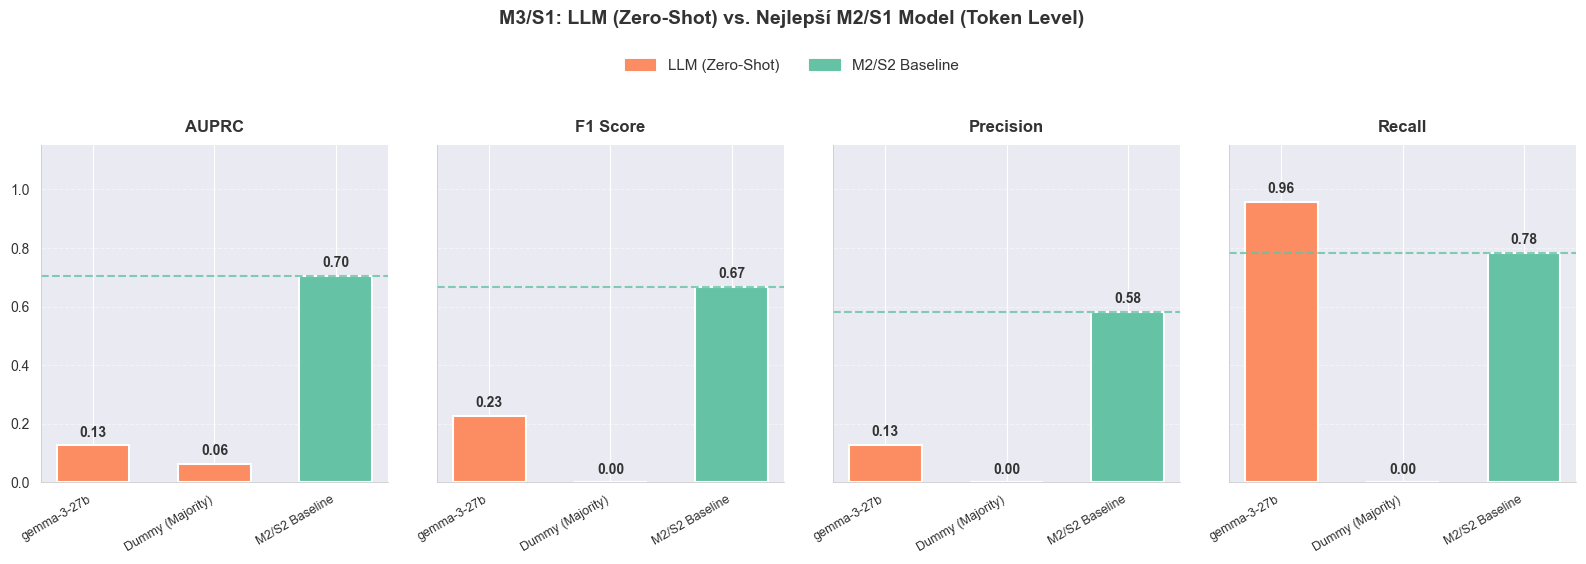

In [8]:
# ==========================================
# 1. Načtení nejlepšího M2/S1 modelu (baseline, podle AUPRC)
# ==========================================
M2_S1_path = config.RESULTS_DIR / "M2_S1_experiment_results_v3.csv"
TARGET_METRIC = 'test_auprc'

try:
    df_m2_results = pd.read_csv(M2_S1_path)
    
    # Filtrujeme baseline scénář (S1a) pro férovost (stejná data jako LLM)
    df_m2_baseline = df_m2_results[df_m2_results['id'] == 'S1a'].copy()
    
    # Nejlepší model podle AUPRC
    df_m2_best = df_m2_baseline.loc[df_m2_baseline[TARGET_METRIC].idxmax()].to_frame().T
    
    print(f"\u2705 Baseline Model (z M2/S1) nalezen!")
    print(f"\U0001f3c6 Model: {df_m2_best['model'].iloc[0]} | AUPRC: {df_m2_best[TARGET_METRIC].iloc[0]:.4f}")

    # ==========================================
    # 2. Vykreslení srovnání LLM vs M2/S1
    # ==========================================
    metrics_to_plot = [m for m in ['auprc', 'f1', 'precision', 'recall'] if m in df_llm_metrics.columns]

    print("\n\U0001f4ca Vykresluji porovnání...")
    visualization.plot_llm_vs_m2_comparison(
        df_llm_metrics=df_llm_metrics,
        df_m2_best=df_m2_best,
        metrics=metrics_to_plot,
        title="M3/S1: LLM (Zero-Shot) vs. Nejlepší M2/S1 Model (Token Level)",
        save_path=config.RESULTS_DIR / "M3_S1_LLM_vs_M2_plot.png"
    )

except FileNotFoundError:
    print(f"\u274c Soubor s M2/S1 výsledky nebyl nalezen: {M2_S1_path}")
except Exception as e:
    print(f"\u274c Chyba: {e}")

### Master Overview (plot_experiment_results)

Sjednocený přehled: LLM vs. M2/S1 Baseline vs. Dummy.

📊 Master Overview DataFrame:


,id,scenario,scenario_name,model,test_f1,test_auprc,test_prec,test_rec
0,M3_S1,llm_zeroshot,LLM Zero-Shot,gemma-3-27b,0.226804,0.125760,0.128655,0.956522
1,M3_S1,llm_zeroshot,LLM Zero-Shot,Dummy (Majority),0.000000,0.062078,0.000000,0.000000
2,M2_S1a,supervised_baseline,M2/S1 Supervised,SVM (RBF) (M2/S1),0.666667,0.703809,0.580645,0.782609


2026-03-13 12:29:46,514 - INFO - Saved experiment results plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_experiment_overview_f1.png


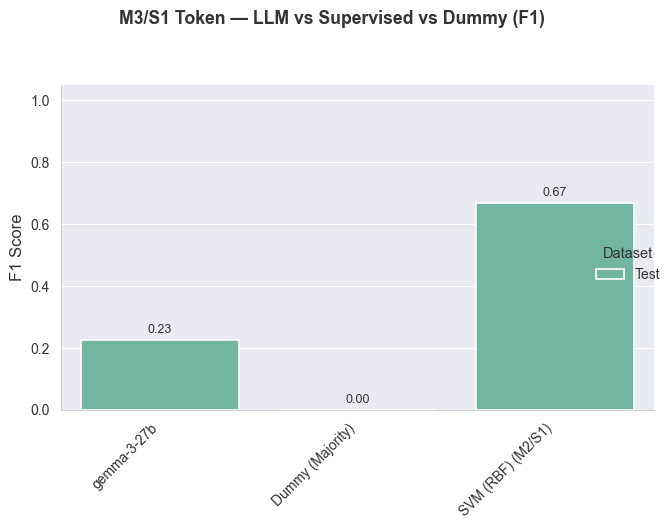

2026-03-13 12:29:46,758 - INFO - Saved experiment results plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_experiment_overview_auprc.png


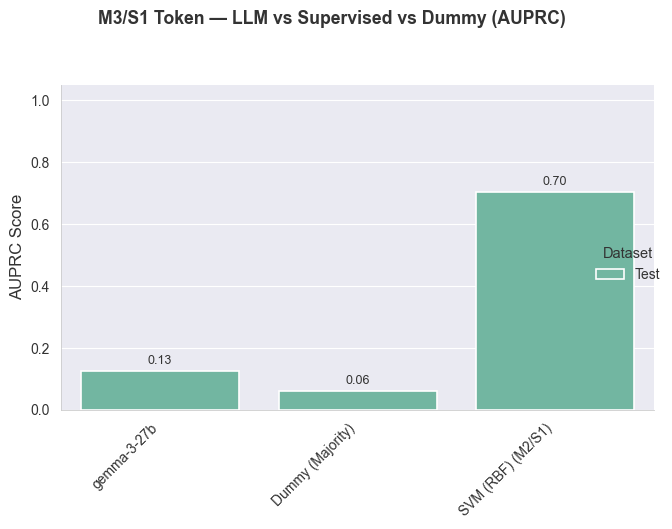

In [9]:
# Sestavení sjednoceného DataFrame pro plot_experiment_results
# Potřebujeme sloupce: model, test_f1, test_auprc, id/scenario

rows = []

# LLM metriky
for _, row in df_llm_metrics.iterrows():
    rows.append({
        'id': 'M3_S1', 'scenario': 'llm_zeroshot', 'scenario_name': 'LLM Zero-Shot',
        'model': row['model'],
        'test_f1': row['f1'], 'test_auprc': row['auprc'],
        'test_prec': row['precision'], 'test_rec': row['recall'],
    })

# M2/S1 Baseline nejlepší model
try:
    best = df_m2_best.iloc[0]
    rows.append({
        'id': 'M2_S1a', 'scenario': 'supervised_baseline', 'scenario_name': 'M2/S1 Supervised',
        'model': f"{best['model']} (M2/S1)",
        'test_f1': best['test_f1'], 'test_auprc': best['test_auprc'],
        'test_prec': best['test_prec'], 'test_rec': best['test_rec'],
    })
except:
    print("\u26a0\ufe0f M2/S1 data not available for master plot.")

df_overview = pd.DataFrame(rows)

print("\U0001f4ca Master Overview DataFrame:")
display(df_overview)

# Vykreslení
visualization.plot_experiment_results(
    df_overview, metric='f1', facet_col=None,
    title_prefix="M3/S1 Token — LLM vs Supervised vs Dummy",
    save_path=config.RESULTS_DIR / "M3_S1_experiment_overview_f1.png"
)

visualization.plot_experiment_results(
    df_overview, metric='auprc', facet_col=None,
    title_prefix="M3/S1 Token — LLM vs Supervised vs Dummy",
    save_path=config.RESULTS_DIR / "M3_S1_experiment_overview_auprc.png"
)

## 7. Deep Dive: Best LLM Model

Confusion Matrix (Normalized + Raw) a Classification Report.

2026-03-13 12:30:04,906 - INFO - 💾 Saved confusion matrix to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_confusion_matrix_norm.png


🏆 Best LLM Model (by AUPRC): gemma-3-27b


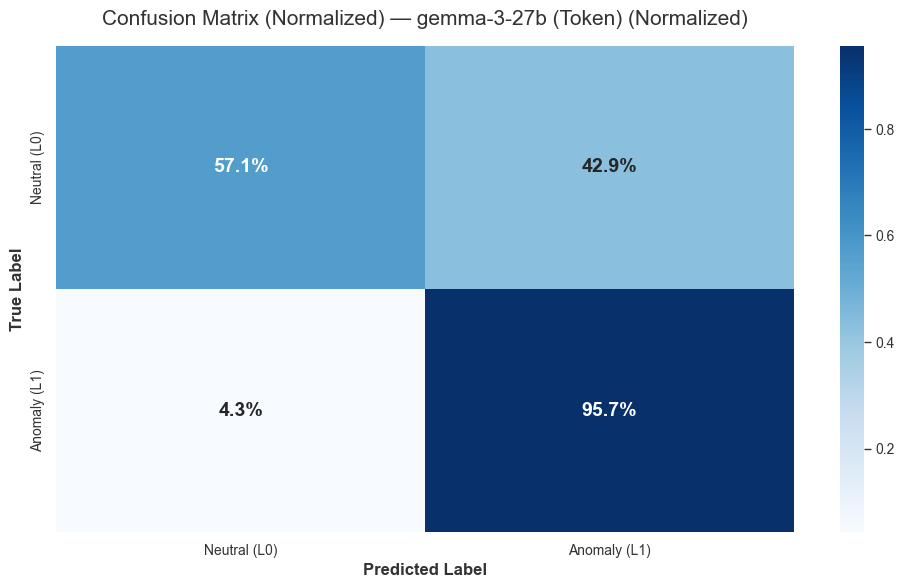

2026-03-13 12:30:05,169 - INFO - 💾 Saved confusion matrix to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_confusion_matrix.png


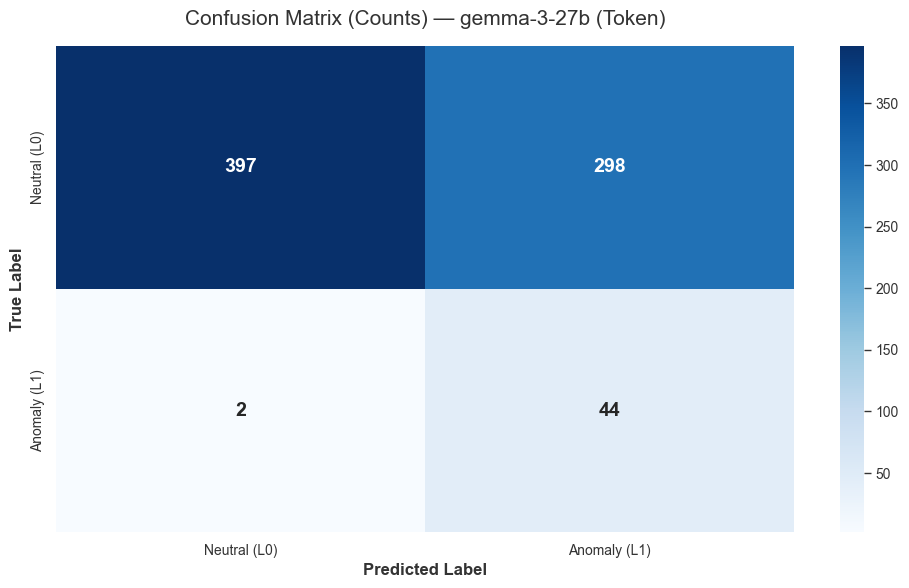


📋 CLASSIFICATION REPORT — gemma-3-27b
              precision    recall  f1-score   support

 Neutral (0)     0.9950    0.5712    0.7258       695
    Bias (1)     0.1287    0.9565    0.2268        46

    accuracy                         0.5951       741
   macro avg     0.5618    0.7639    0.4763       741
weighted avg     0.9412    0.5951    0.6948       741



In [10]:
# ==========================================
# Výběr nejlepšího LLM modelu podle AUPRC
# ==========================================
best_llm_row = df_llm_metrics[df_llm_metrics['model'] != 'Dummy (Majority)'].sort_values('auprc', ascending=False).iloc[0]
best_llm_name = best_llm_row['model']
best_llm_col = f"pred_{best_llm_name}"

print(f"\U0001f3c6 Best LLM Model (by AUPRC): {best_llm_name}")

# Filtrujeme na řádky s validními predikcemi
df_valid = df_results.dropna(subset=[best_llm_col]).copy()
y_true = df_valid['true_label'].astype(int).values
y_pred = df_valid[best_llm_col].astype(int).values

# ==========================================
# Confusion Matrix (Normalized)
# ==========================================
visualization.plot_confusion_matrix_heatmap(
    y_true, y_pred, normalize=True,
    title=f"Confusion Matrix (Normalized) — {best_llm_name} (Token)",
    save_path=config.RESULTS_DIR / "M3_S1_confusion_matrix_norm.png"
)

# ==========================================
# Confusion Matrix (Raw Counts)
# ==========================================
visualization.plot_confusion_matrix_heatmap(
    y_true, y_pred, normalize=False,
    title=f"Confusion Matrix (Counts) — {best_llm_name} (Token)",
    save_path=config.RESULTS_DIR / "M3_S1_confusion_matrix.png"
)

# ==========================================
# Classification Report
# ==========================================
print("\n" + "=" * 60)
print(f"\U0001f4cb CLASSIFICATION REPORT — {best_llm_name}")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=['Neutral (0)', 'Bias (1)'], digits=4))

## 8. Qualitative Analysis (Error Analysis)

Konkrétní příklady tokenů, které model nesprávně klasifikoval — False Positives (falešný poplach) a False Negatives (přehlédnutý bias).

### Embedding Projections (Error Analysis)

Vizualizace chyb LLM modelu v embedding prostoru. Použijeme PCA, t-SNE a UMAP projekci testovacích embeddingů, obarvenou podle Ground Truth a podle kategorie predikce (TP, FP, TN, FN).

2026-03-13 12:45:50,060 - INFO - 1️⃣ Computing PCA...
2026-03-13 12:45:50,114 - INFO - 2️⃣ Computing t-SNE...
2026-03-13 12:45:56,103 - INFO - 3️⃣ Computing UMAP...



🔹 Vizualizace: PCA


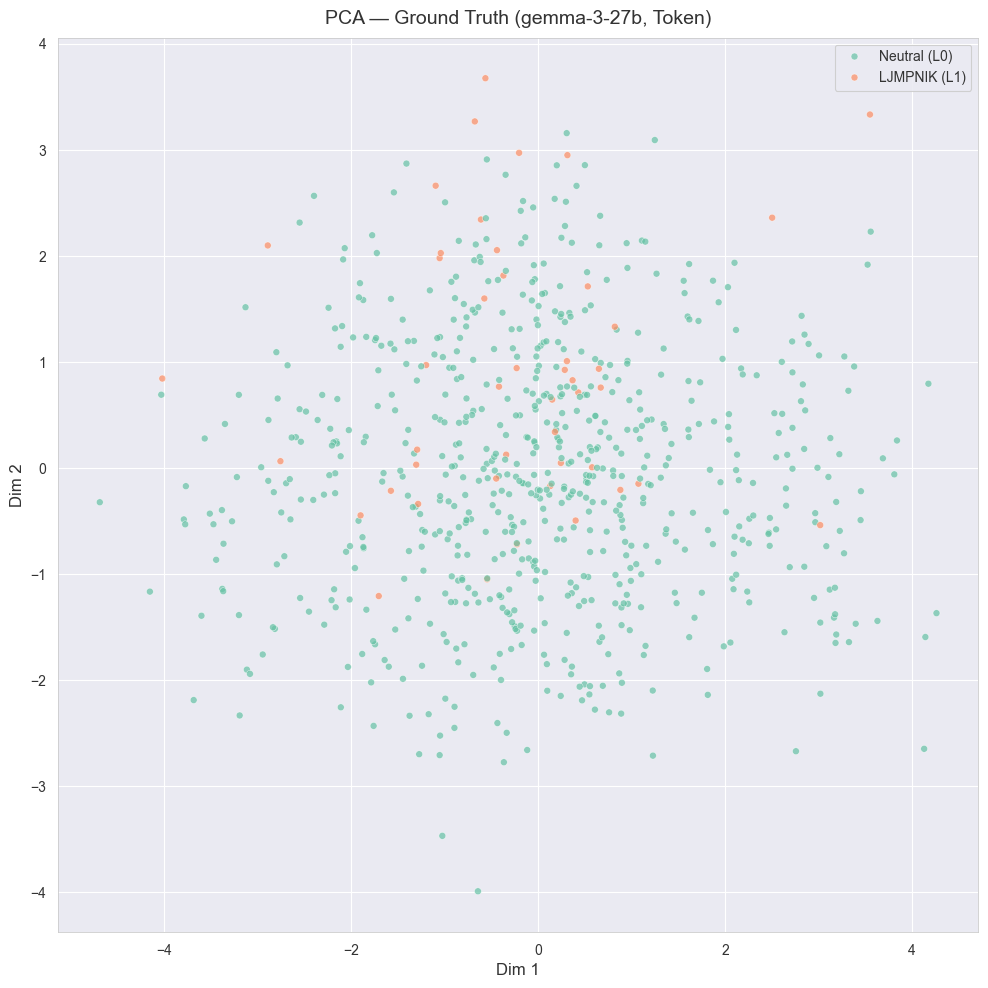

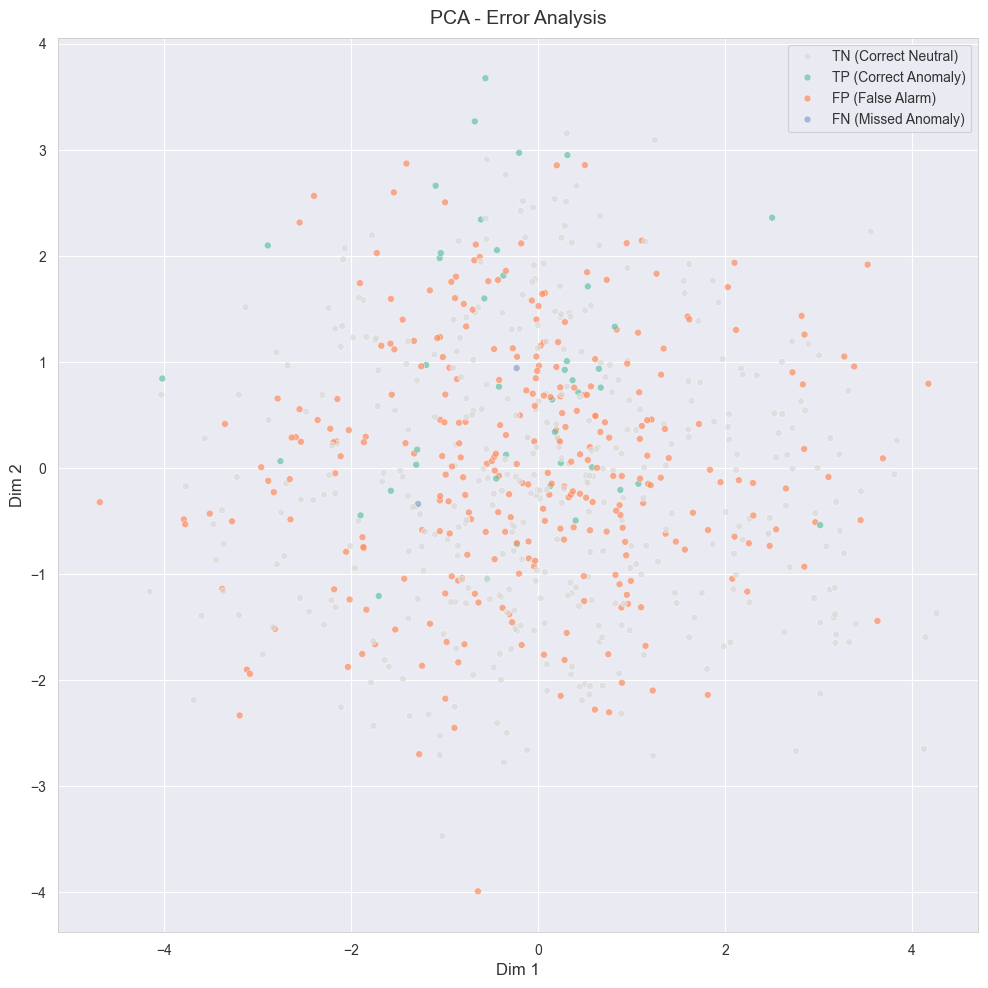


🔹 Vizualizace: t-SNE


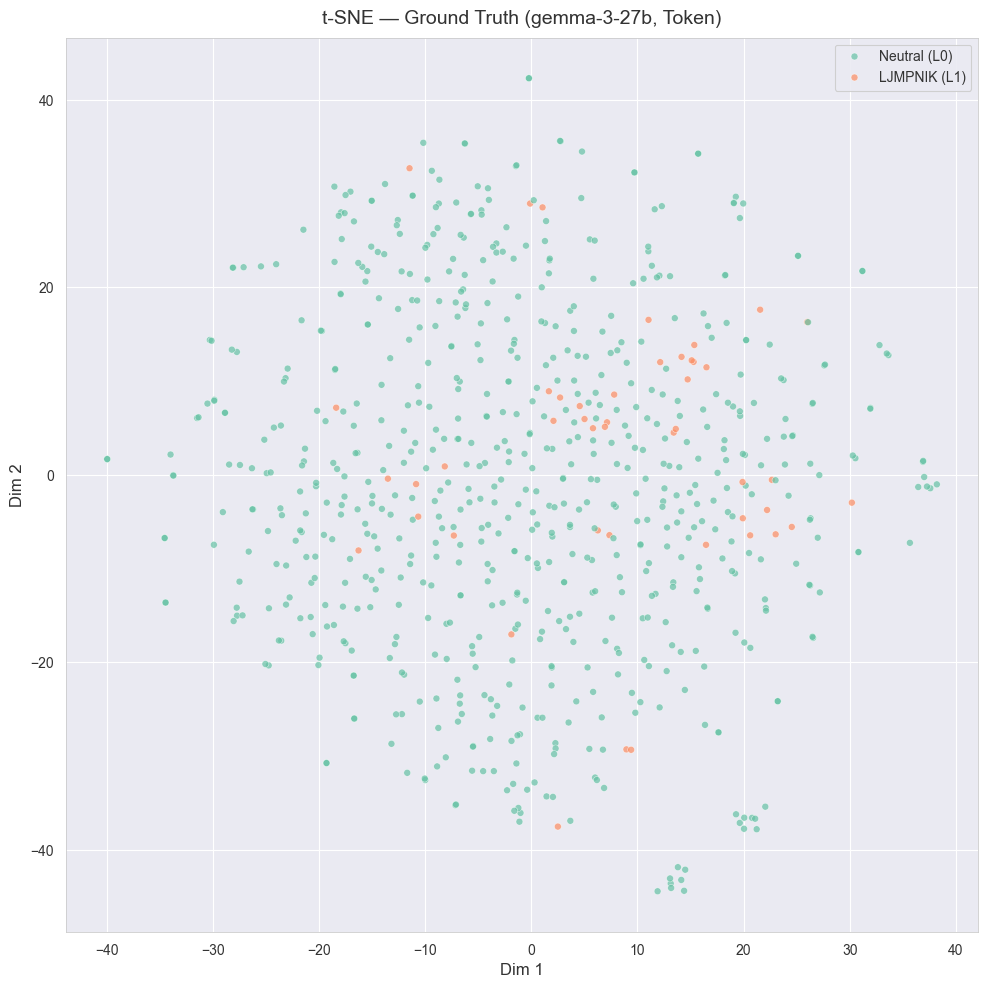

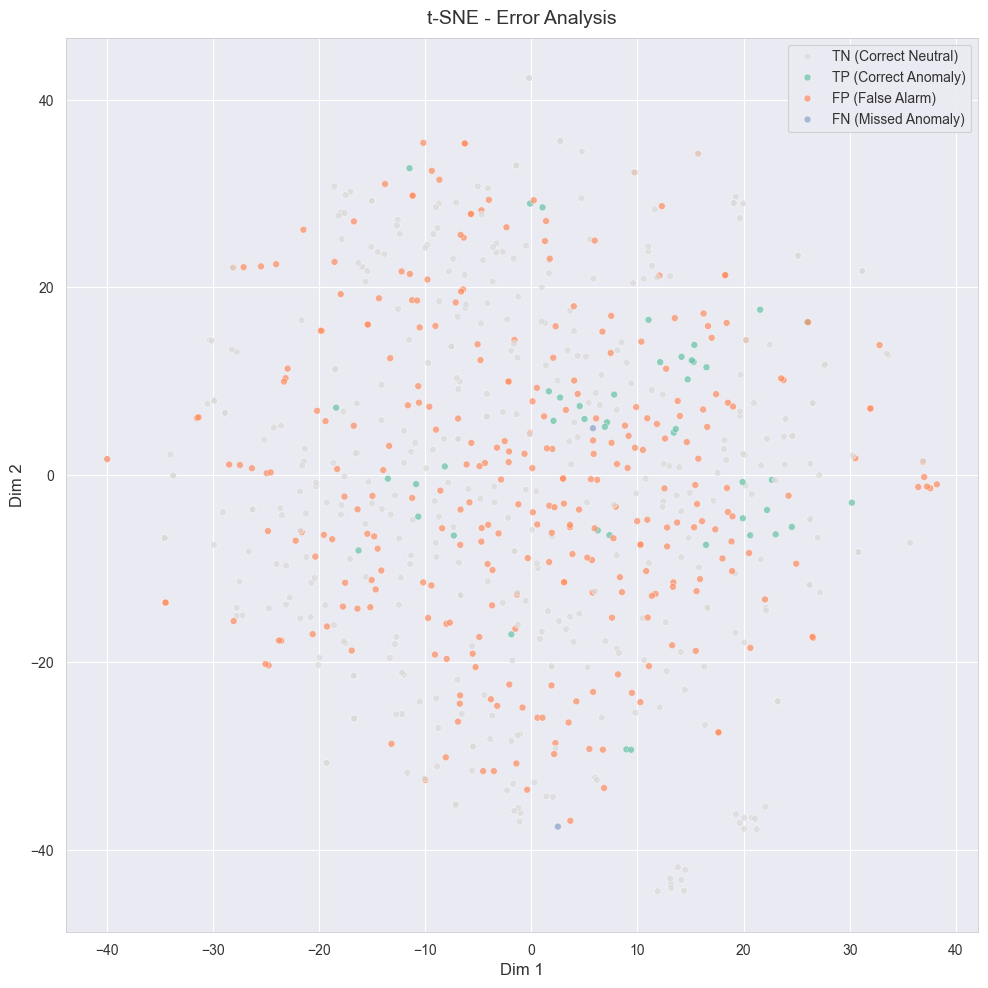


🔹 Vizualizace: UMAP


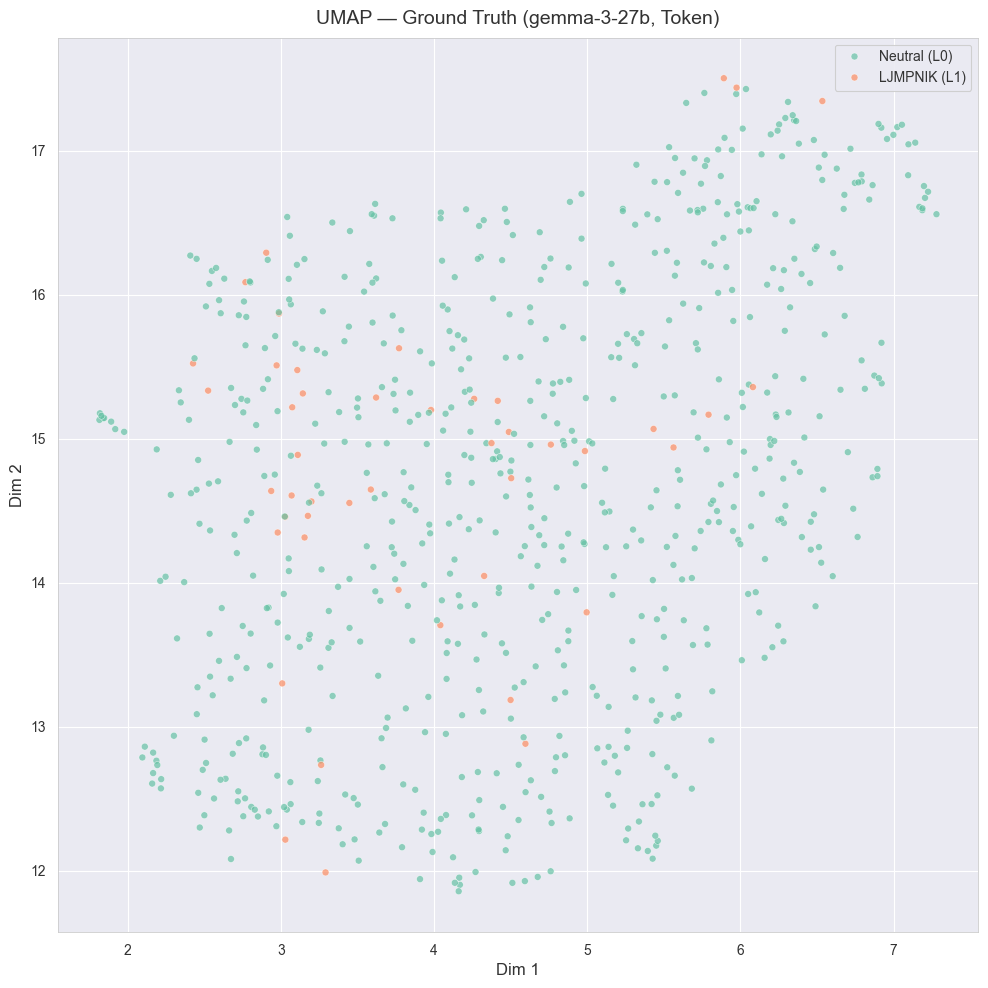

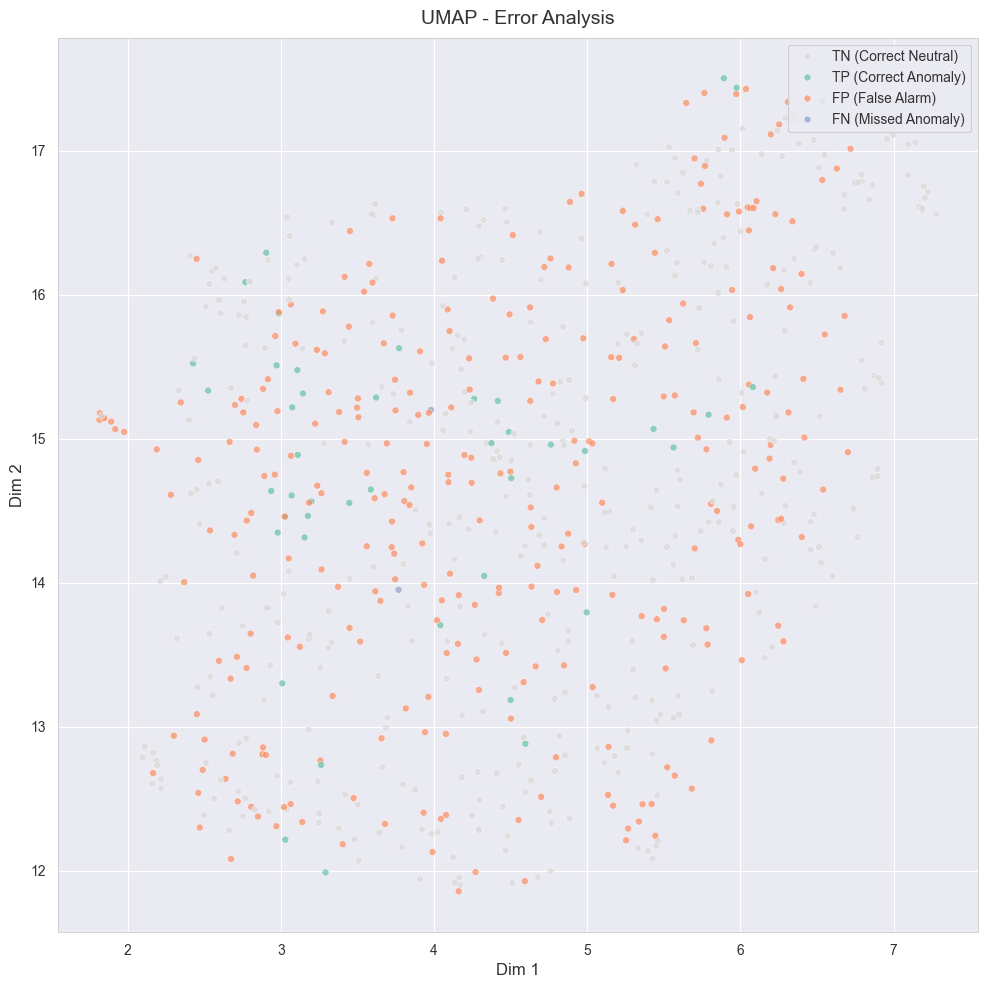


✅ Všechny projekce uloženy.


In [12]:
# ==========================================
# Embedding Projections — Error Analysis
# ==========================================
X_test = data['X_test']

# Compute PCA + t-SNE + UMAP projections
projs, idxs = visualization.compute_projections(
    X_test, methods=['PCA', 't-SNE', 'UMAP'], random_state=42
)

y_viz = y_true[idxs]
y_pred_viz = y_pred[idxs]

for method_name, coords in projs.items():
    print(f"\n🔹 Vizualizace: {method_name}")
    
    # --- A) Ground Truth projection ---
    labels_gt = pd.Series(y_viz).map({0: 'Neutral (L0)', 1: 'LJMPNIK (L1)'})
    
    visualization.plot_embedding_projection(
        coords,
        labels_gt,
        palette={'Neutral (L0)': config.COLORS['l0'], 'LJMPNIK (L1)': config.COLORS['l1']},
        title=f"{method_name} — Ground Truth ({best_llm_name}, Token)",
        hue_order=['Neutral (L0)', 'LJMPNIK (L1)'],
        save_path=config.RESULTS_DIR / f"M3_S1_{method_name}_ground_truth.png"
    )
    
    # --- B) Error Analysis projection (TP, FP, TN, FN) ---
    visualization.plot_error_analysis_projection(
        coords, y_viz, y_pred_viz,
        method_name=method_name,
        save_path=config.RESULTS_DIR / f"M3_S1_{method_name}_error_analysis.png"
    )

print("\n✅ Všechny projekce uloženy.")

In [11]:
# ==========================================
# Qualitative Error Analysis
# ==========================================
df_qual = df_valid[['document_id', 'sentence_id', 'form', 'pos', 'sentence_context', 'true_label']].copy()
df_qual['pred_label'] = y_pred

# Kategorizace predikce (TP / TN / FP / FN)
conds = [
    (df_qual['true_label'] == 1) & (df_qual['pred_label'] == 1),
    (df_qual['true_label'] == 0) & (df_qual['pred_label'] == 0),
    (df_qual['true_label'] == 0) & (df_qual['pred_label'] == 1),
    (df_qual['true_label'] == 1) & (df_qual['pred_label'] == 0),
]
df_qual['category'] = np.select(conds, ['TP', 'TN', 'FP', 'FN'], default='UNKNOWN')

# Distribuce kategorií
print("\U0001f4ca Distribuce kategorií predikce:")
display(df_qual['category'].value_counts().to_frame('count'))

# --- False Positives ---
df_fp = df_qual[df_qual['category'] == 'FP'].copy()
print(f"\n\u274c FALSE POSITIVES — Model označil neutrální slovo jako bias ({len(df_fp)} tokenů):")
display(df_fp[['form', 'pos', 'sentence_context', 'document_id']].head(10))

# --- False Negatives ---
df_fn = df_qual[df_qual['category'] == 'FN'].copy()
print(f"\n\u274c FALSE NEGATIVES — Model přehlédl biased slovo ({len(df_fn)} tokenů):")
display(df_fn[['form', 'pos', 'sentence_context', 'document_id']].head(10))

# Uložení
qual_path = config.RESULTS_DIR / "M3_S1_Qualitative_Analysis.csv"
df_qual.to_csv(qual_path, index=False)
print(f"\n\U0001f4be Qualitative analysis uložena: {qual_path}")

📊 Distribuce kategorií predikce:


,count
category,
TN,397
FP,298
TP,44
FN,2



❌ FALSE POSITIVES — Model označil neutrální slovo jako bias (298 tokenů):


,form,pos,sentence_context,document_id
0,Tempo,NOUN,Tempo výstavby nových bytů žalostné,gold_doc_0003
1,výstavby,NOUN,Tempo výstavby nových bytů žalostné,gold_doc_0003
2,nových,ADJ,Tempo výstavby nových bytů žalostné,gold_doc_0003
3,bytů,NOUN,Tempo výstavby nových bytů žalostné,gold_doc_0003
5,Produktivita,NOUN,Produktivita práce odvětvích mizerná,gold_doc_0007
6,práce,NOUN,Produktivita práce odvětvích mizerná,gold_doc_0007
7,odvětvích,NOUN,Produktivita práce odvětvích mizerná,gold_doc_0007
9,Úroveň,NOUN,Úroveň čistoty vozidlech otřesná,gold_doc_0010
10,čistoty,NOUN,Úroveň čistoty vozidlech otřesná,gold_doc_0010
11,vozidlech,NOUN,Úroveň čistoty vozidlech otřesná,gold_doc_0010



❌ FALSE NEGATIVES — Model přehlédl biased slovo (2 tokenů):


,form,pos,sentence_context,document_id
77,bikesharing,NOUN,Dodal firma chce zaměřit jednání městem nastav...,gold_doc_0056
370,zhruba,ADV,Město plánování průmyslového parku rozloze zhr...,gold_doc_0242



💾 Qualitative analysis uložena: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_Qualitative_Analysis.csv
